In [140]:
import zipfile

In [84]:
from google.colab import files
uploaded = files.upload()

Saving online+retail.zip to online+retail (2).zip


In [85]:
zip_path = "/content/online+retail.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    print(z.namelist())

['Online Retail.xlsx']


In [86]:
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("/content/retail")

In [87]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [88]:
df = pd.read_excel("/content/retail/Online Retail.xlsx")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [89]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [90]:
print(df.dtypes)

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


In [91]:
print(df.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [92]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None


In [93]:
print("Shape of dataset:",df.shape)

Shape of dataset: (541909, 8)


In [94]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [95]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [96]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [97]:
df = df.dropna(subset=['CustomerID'])
print("Rows after removing missing CustomerID:", len(df))

Rows after removing missing CustomerID: 406829


In [98]:
df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 401604


In [99]:
df = df[df['Quantity'] > 0]

print("Rows after removing invalid quantities:", len(df))

Rows after removing invalid quantities: 392732


In [100]:
df = df[df['UnitPrice'] > 0]

print("Rows after removing invalid prices:", len(df))

Rows after removing invalid prices: 392692


In [101]:
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [102]:
print("Final rows:", len(df))
print("Final columns:", df.shape)
print(df.isnull().sum())

Final rows: 392692
Final columns: (392692, 9)
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalSales     0
dtype: int64


In [103]:
total_sales = df['TotalSales'].sum()

print("Total Sales:", total_sales)

Total Sales: 8887208.894


In [104]:
unique_customers = df['CustomerID'].nunique()

print("Number of Customers:", unique_customers)

Number of Customers: 4338


In [105]:
unique_products = df['StockCode'].nunique()

print("Number of Products:", unique_products)

Number of Products: 3665


In [106]:
country_sales = df.groupby('Country')['TotalSales'].sum().sort_values(ascending=False)

print(country_sales.head(10))

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalSales, dtype: float64


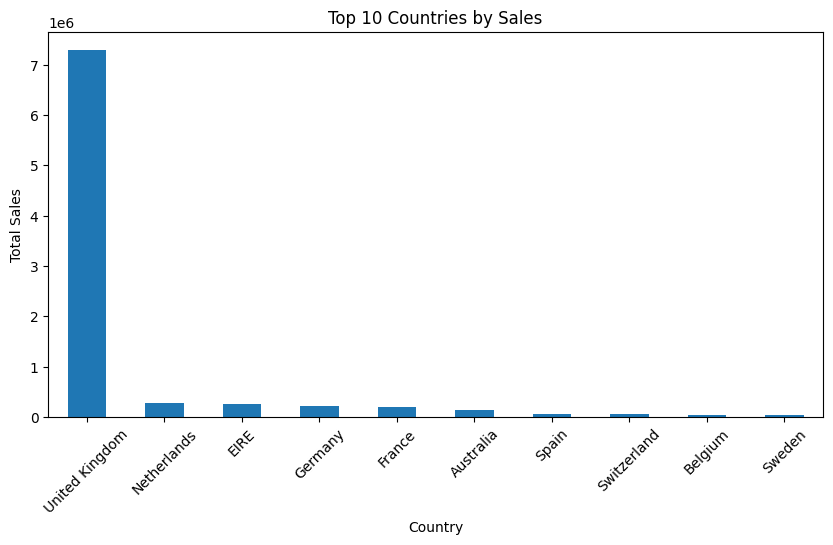

In [107]:
plt.figure(figsize=(10,5))

country_sales.head(10).plot(kind='bar')

plt.title('Top 10 Countries by Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [108]:
product_sales = df.groupby('Description')['TotalSales'].sum().sort_values(ascending=False)

print(product_sales.head(10))

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalSales, dtype: float64


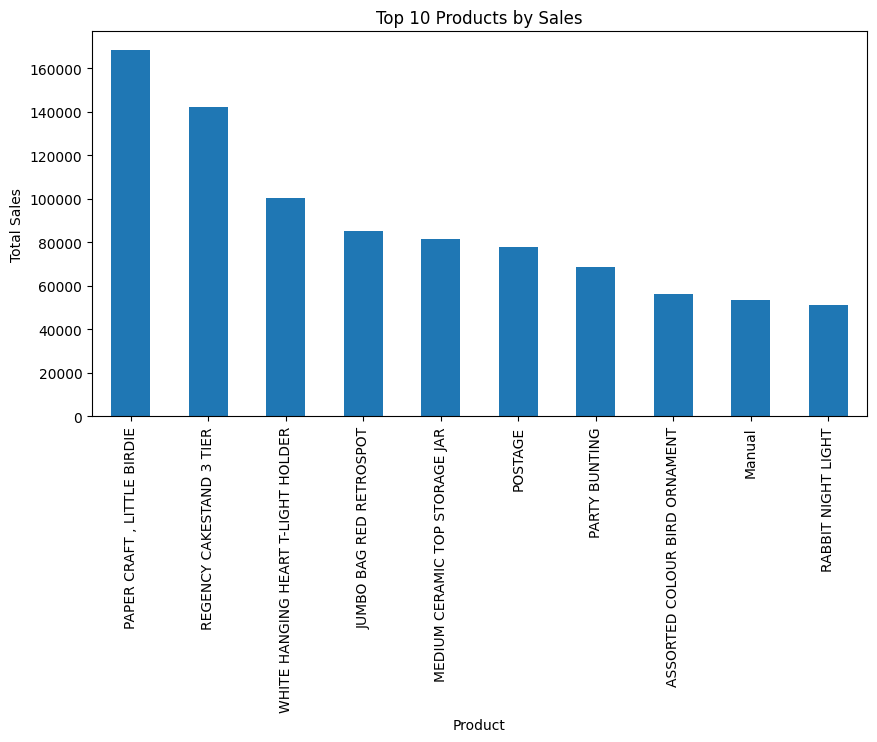

In [109]:
plt.figure(figsize=(10,5))

product_sales.head(10).plot(kind='bar')

plt.title('Top 10 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.show()

In [110]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [111]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [112]:
monthly_sales = df.groupby('Month')['TotalSales'].sum()

print(monthly_sales)

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: TotalSales, dtype: float64


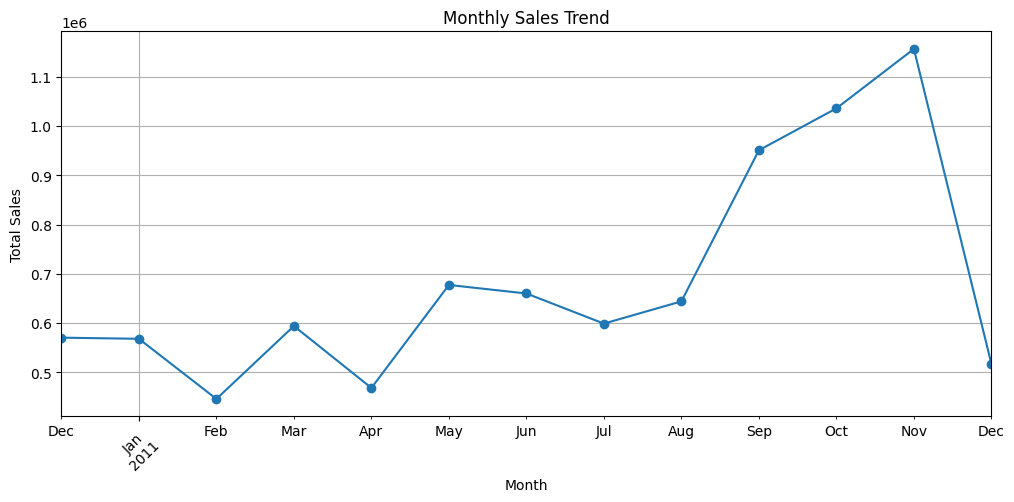

In [113]:
plt.figure(figsize=(12,5))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid()
plt.show()

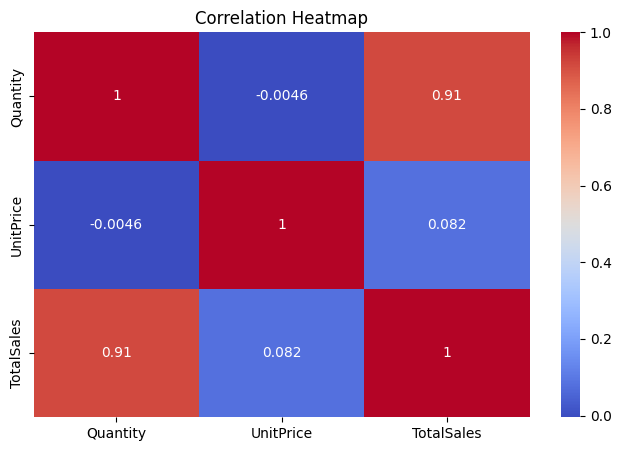

In [114]:
plt.figure(figsize=(8,5))

corr = df[['Quantity', 'UnitPrice', 'TotalSales']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [115]:
print("Last purchase date:", df['InvoiceDate'].max())

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference date:", reference_date)

Last purchase date: 2011-12-09 12:50:00
Reference date: 2011-12-10 12:50:00


In [116]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalSales': 'sum'
})

In [117]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [118]:
print("Number of customers:", len(rfm))
print("Columns:", rfm.columns.tolist())

Number of customers: 4338
Columns: ['Recency', 'Frequency', 'Monetary']


In [119]:
print(rfm.isnull().sum())

Recency      0
Frequency    0
Monetary     0
dtype: int64


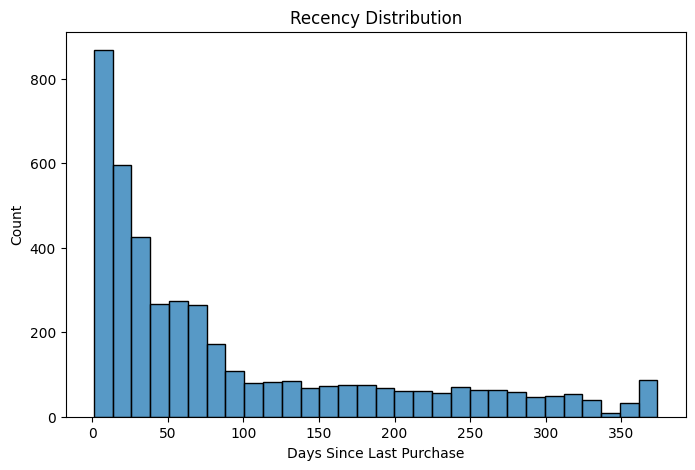

In [120]:
plt.figure(figsize=(8,5))

sns.histplot(rfm['Recency'], bins=30)

plt.title('Recency Distribution')
plt.xlabel('Days Since Last Purchase')
plt.show()

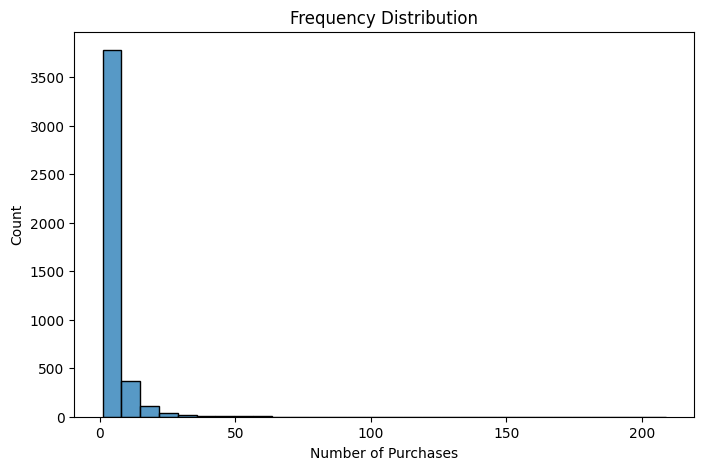

In [121]:
plt.figure(figsize=(8,5))

sns.histplot(rfm['Frequency'], bins=30)

plt.title('Frequency Distribution')
plt.xlabel('Number of Purchases')
plt.show()

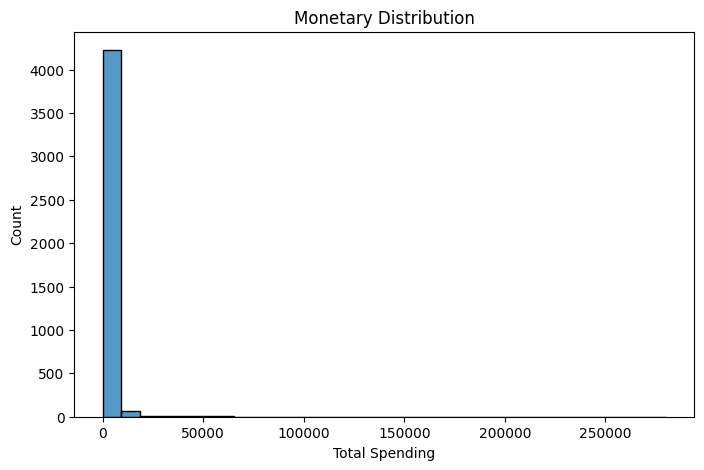

In [122]:
plt.figure(figsize=(8,5))

sns.histplot(rfm['Monetary'], bins=30)

plt.title('Monetary Distribution')
plt.xlabel('Total Spending')
plt.show()

In [123]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

print("RFM data standardized successfully!")

RFM data standardized successfully!


In [124]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


In [125]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

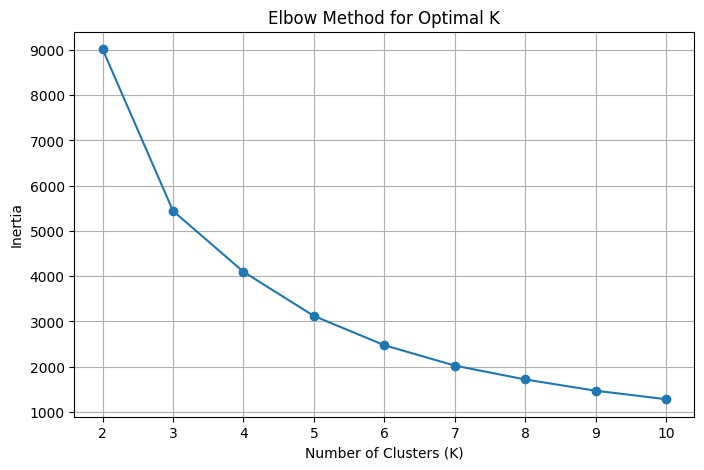

In [126]:
plt.figure(figsize=(8,5))

plt.plot(range(2, 11), inertia, marker='o')

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))
plt.grid()

plt.show()

In [127]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [128]:
print(rfm['Cluster'].value_counts().sort_index())

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


In [129]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


In [130]:
segment_names = {
    0: 'Regular Customers',
    1: 'Inactive Customers',
    2: 'VIP Customers',
    3: 'Loyal High-Value Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Loyal High-Value Customers
12347.0,2,7,4310.00,0,Regular Customers
12348.0,75,4,1797.24,0,Regular Customers
12349.0,19,1,1757.55,0,Regular Customers
12350.0,310,1,334.40,1,Inactive Customers


In [131]:
segment_counts = rfm['Segment'].value_counts()

print(segment_counts)

Segment
Regular Customers             3054
Inactive Customers            1067
Loyal High-Value Customers     204
VIP Customers                   13
Name: count, dtype: int64


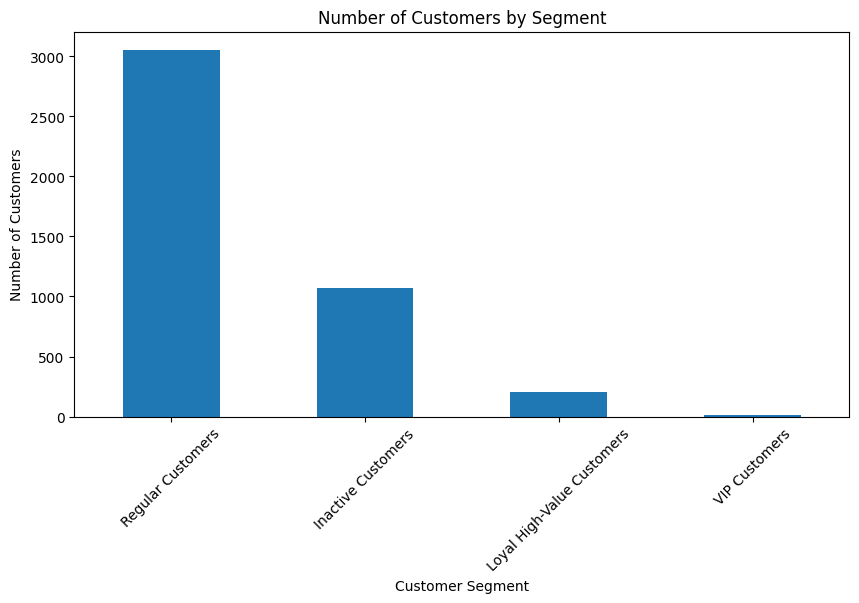

In [132]:
plt.figure(figsize=(10,5))

segment_counts.plot(kind='bar')

plt.title('Number of Customers by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

plt.show()

In [133]:
segment_sales = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

print(segment_sales)

Segment
Regular Customers             4133971.703
Loyal High-Value Customers    2588862.080
VIP Customers                 1653443.470
Inactive Customers             510931.641
Name: Monetary, dtype: float64


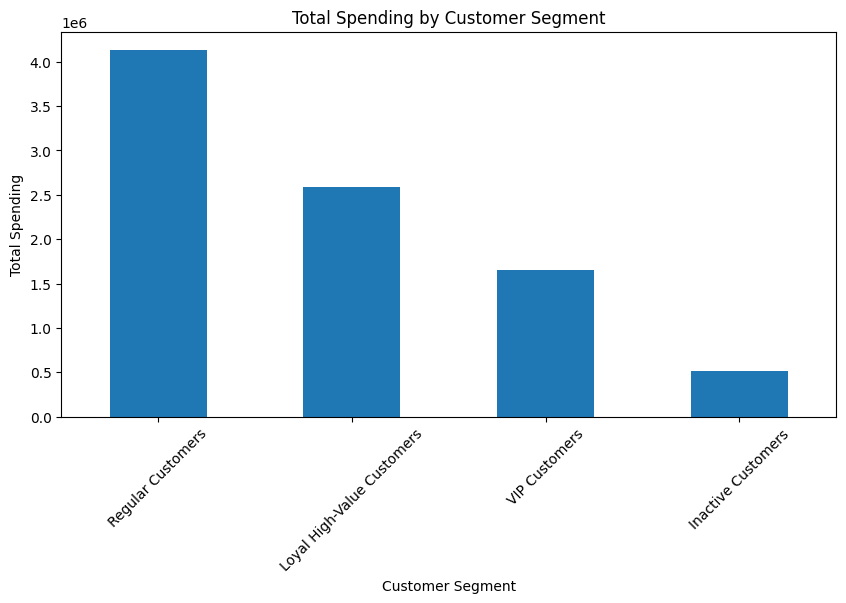

In [134]:
plt.figure(figsize=(10,5))

segment_sales.plot(kind='bar')

plt.title('Total Spending by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Spending')
plt.xticks(rotation=45)

plt.show()

In [135]:
df_final = df.merge(
    rfm[['Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']],
    on='CustomerID',
    how='left'
)

df_final.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Month,Recency,Frequency,Monetary,Cluster,Segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,372,34,5391.21,3,Loyal High-Value Customers
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,372,34,5391.21,3,Loyal High-Value Customers
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,372,34,5391.21,3,Loyal High-Value Customers
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,372,34,5391.21,3,Loyal High-Value Customers
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,372,34,5391.21,3,Loyal High-Value Customers


In [136]:
print("Columns:", df_final.shape)

Columns: (392692, 15)


In [137]:
df_final[['CustomerID', 'TotalSales', 'Cluster', 'Segment']].head(10)

,CustomerID,TotalSales,Cluster,Segment
0,17850.0,15.30,3,Loyal High-Value Customers
1,17850.0,20.34,3,Loyal High-Value Customers
2,17850.0,22.00,3,Loyal High-Value Customers
3,17850.0,20.34,3,Loyal High-Value Customers
4,17850.0,20.34,3,Loyal High-Value Customers
5,17850.0,15.30,3,Loyal High-Value Customers
6,17850.0,25.50,3,Loyal High-Value Customers
7,17850.0,11.10,3,Loyal High-Value Customers
8,17850.0,11.10,3,Loyal High-Value Customers
9,13047.0,54.08,0,Regular Customers


In [138]:
df_final.to_csv(
    '/content/customer_segmentation_sales.csv',
    index=False
)

print("Final CSV created successfully!")

Final CSV created successfully!


In [139]:
import os

print(os.path.getsize('/content/customer_segmentation_sales.csv'), "bytes")

55530192 bytes
